### Test de coherencia de genero

In [2]:
import faiss
import pandas as pd

INDEX_PATH = "../data/processed/faiss.index"
INDEX_META_PATH = "../data/processed/index_metadata.csv"

index=faiss.read_index(INDEX_PATH)
metadata=pd.read_csv(INDEX_META_PATH)
metadata.head()
k=5

In [ ]:
from sklearn.metrics import jaccard_score
from sklearn.preprocessing import MultiLabelBinarizer

N_SAMPLES=500
# tomamos los mismos 500 samples siempre
sample=metadata.sample(N_SAMPLES, random_state=42)
metadata['genre_list'] = metadata['genres'].fillna('').apply(lambda x: [g.strip().lower() for g in x.split(", ")] if x else [])


mlb = MultiLabelBinarizer()
generos_binarios = mlb.fit_transform(metadata['genre_list'])


import numpy as np
def jaccard_score_manual(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / union if union != 0 else 0.0

scores_totales_manual = []
scores_recomendaciones = []
umbral_jaccard = 0.5
aciertos = 0

for idx, row in sample.iterrows():
    # 1. Recuperar vector y buscar en FAISS
    vector = index.reconstruct(idx)
    # k+1 para saltar la misma película
    socres, indices = index.search(vector.reshape(1, -1), k+1)
    # 2. Obtener los vectores binarios de las recomendaciones (excluyendo el primero)
    indices_recomendados = indices[0][1:]
    
    # El vector binario de la película original (query)
    y_true = generos_binarios[idx] 
    
    # Los vectores binarios de las 5 recomendadas
    y_preds = generos_binarios[indices_recomendados]
    
    # 3. Calcular Jaccard para este set de 5 películas
    # 'samples' calcula el Jaccard para cada par y devuelve el promedio
    # Necesitamos repetir y_true para que tenga la misma forma que y_preds
    # Tomamos como acierto cuando la recomendación supera el umbral de jaccard
    y_true_repeated = np.tile(y_true, (len(y_preds), 1))
    
    score_pelicula_k_recomendaciones = 0
    for y_true,y_pred in zip(y_true_repeated,y_preds):
        score_recomendacion=jaccard_score_manual(y_true, y_pred)
        scores_recomendaciones.append(score_recomendacion)
        score_pelicula_k_recomendaciones+=score_recomendacion
        if (score_recomendacion) >= umbral_jaccard:
            aciertos += 1
    score_pelicula_k_recomendaciones/=len(y_preds)
    

    
    scores_totales_manual.append(score_pelicula_k_recomendaciones)

print(f"Promedio Jaccard (manual): {np.mean(scores_totales_manual):.4f}")
print(f'Aciertos (Jaccard >= {umbral_jaccard}): {aciertos} de {N_SAMPLES} peliculas y {k} recomendaciones ({aciertos/(N_SAMPLES*5):.2%})')

Promedio Jaccard (manual): 0.3281
Aciertos (Jaccard >= 0.5): 853 de 500 peliculas y 5 recomendaciones (34.12%)


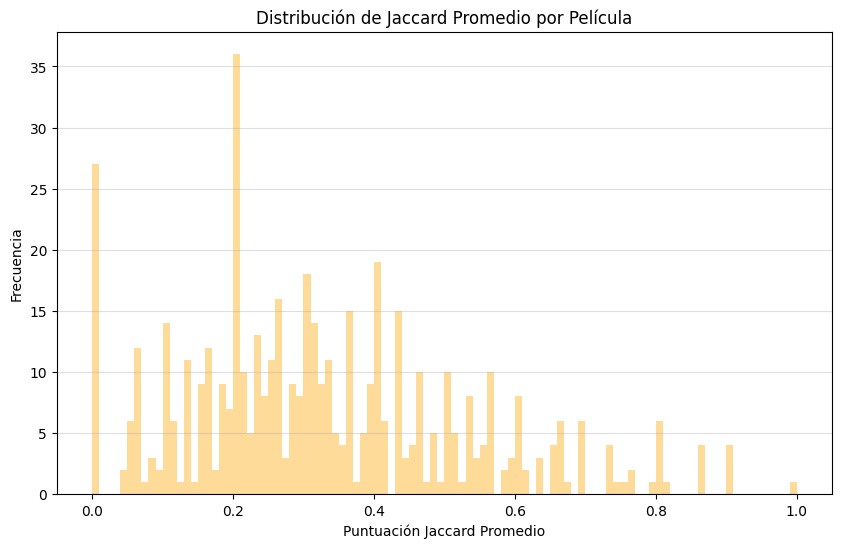

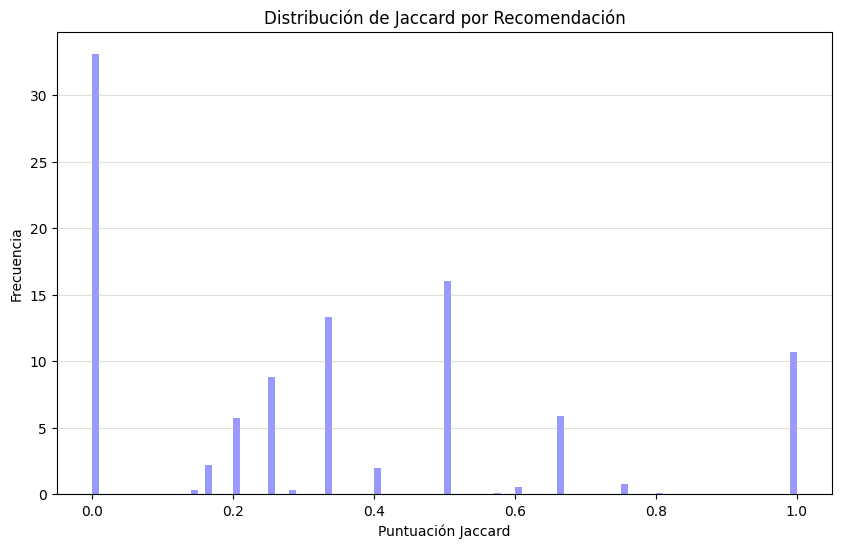

In [ ]:
import matplotlib.pyplot as plt

# Ploteo de las distribuciones de las puntuaciones en un grafico continuo
plt.figure(figsize=(10, 6))
plt.hist(scores_totales_manual, bins=100, alpha=0.4, color='orange')
plt.title('Distribución de Jaccard Promedio por Película')
plt.xlabel('Puntuación Jaccard Promedio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.4)
plt.show()

#Ploteo de todas las puntuaciones individuales de las recomendaciones
plt.figure(figsize=(10, 6))
plt.hist(scores_recomendaciones, bins=100, alpha=0.4, color='blue',density=True)
plt.title('Distribución de Jaccard por Recomendación')
plt.xlabel('Puntuación Jaccard')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.4)
plt.show()


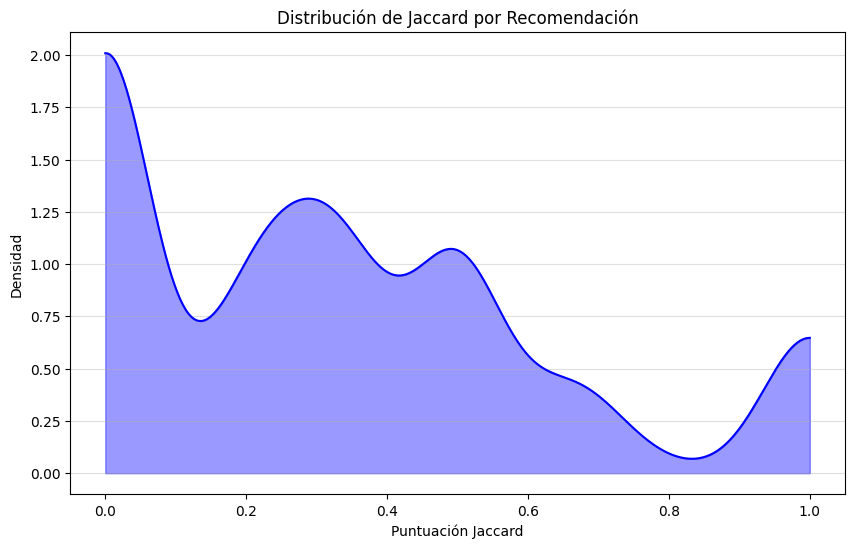

In [5]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(scores_recomendaciones)
x = np.linspace(0, 1, 500)

plt.figure(figsize=(10, 6))
plt.plot(x, kde(x), color='blue')
plt.fill_between(x, kde(x), alpha=0.4, color='blue')
plt.title('Distribución de Jaccard por Recomendación')
plt.xlabel('Puntuación Jaccard')
plt.ylabel('Densidad')
plt.grid(axis='y', alpha=0.4)
plt.show()

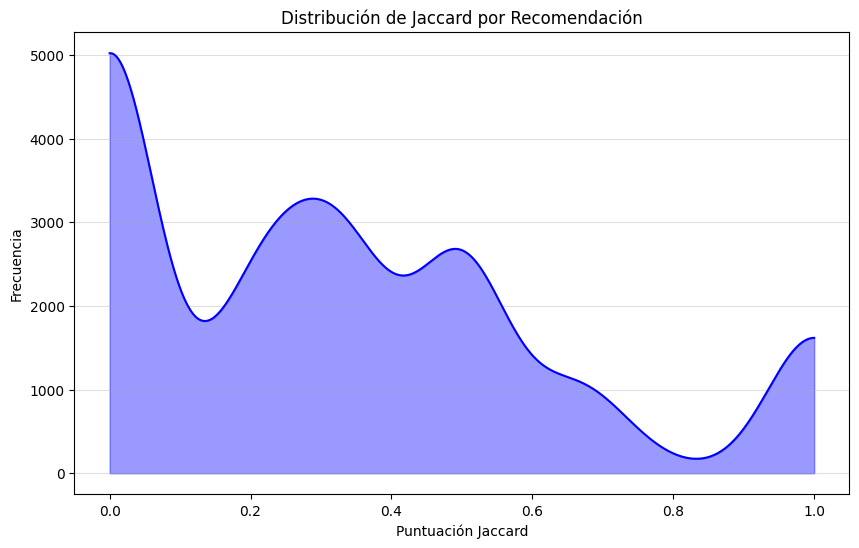

In [6]:
n = len(scores_recomendaciones)
x = np.linspace(0, 1, 500)

plt.figure(figsize=(10, 6))
plt.plot(x, kde(x) * n, color='blue')
plt.fill_between(x, kde(x) * n, alpha=0.4, color='blue')
plt.title('Distribución de Jaccard por Recomendación')
plt.xlabel('Puntuación Jaccard')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.4)
plt.show()

